# Tutorial 15 — Comparing Graph Neural Networks for Molecules
**Author:** Himanshu Goel | [Website](https://hgoelgithub.github.io)

Molecules are natural graphs: atoms are nodes, bonds are edges. GNNs exploit this structure directly — unlike fingerprints, they learn their own features end-to-end. We build a Graph Convolutional Network (GCN) using PyTorch Geometric.

In [10]:
# PyTorch: deep learning framework used to build and train the GCN
!pip install torch -q
# PyTorch Geometric (PyG): extends PyTorch with graph neural network primitives
# (GCNConv, global pooling, DataLoader for graphs, etc.)
!pip install torch-geometric -q
# RDKit: cheminformatics library for parsing SMILES and extracting atom/bond info
# pandas/numpy: data handling; matplotlib: plotting training curves
!pip install rdkit pandas numpy matplotlib -q

In [11]:
# ── Imports ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool  # GCN layer + graph pooling
from torch_geometric.data import Data                     # container for a single graph
from torch_geometric.loader import DataLoader             # batches multiple graphs together
from rdkit import Chem   # parses SMILES strings into molecule objects
import numpy as np
import random

# ── SMILES → PyG graph conversion ────────────────────────────────────────────
def mol_to_graph(smiles: str, label: float):
    """
    Converts a SMILES string into a PyTorch Geometric Data object.

    Node features (one row per atom, 6 columns):
      0 - atomic number / 100          (normalized element identity)
      1 - degree / 6                   (number of bonds the atom participates in)
      2 - formal charge / 2            (charge state, e.g. -1, 0, +1)
      3 - is_aromatic (bool → float)   (part of an aromatic ring?)
      4 - total H count / 4            (implicit + explicit hydrogens)
      5 - is_in_ring (bool → float)    (part of any ring?)

    Edges are undirected: each bond (i,j) is stored twice as (i→j) and (j→i)
    so message passing flows in both directions.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None  # skip malformed SMILES

    # Build node feature matrix X  (shape: num_atoms × 6)
    x = []
    for atom in mol.GetAtoms():
        x.append([
            atom.GetAtomicNum() / 100.0,
            atom.GetDegree() / 6.0,
            atom.GetFormalCharge() / 2.0,
            float(atom.GetIsAromatic()),
            atom.GetTotalNumHs() / 4.0,
            float(atom.IsInRing())
        ])
    x = torch.tensor(x, dtype=torch.float)

    # Build edge index  (shape: 2 × num_edges)
    # PyG uses COO format: row 0 = source nodes, row 1 = destination nodes
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]  # add both directions

    if not edge_index:
        # Isolated atom (no bonds) → empty edge tensor
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    #print(f"Edge index shape: {edge_index.shape}")

    return Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.float))

# ── 215 molecules: hERG cardiotoxicity dataset ────────────────────────────────
# Label 0 = non-blocker  |  Label 1 = hERG blocker (IC50 < 10 µM)
# hERG (human Ether-à-go-go Related Gene) encodes a cardiac K⁺ channel;
# blocking it can cause fatal arrhythmia, so this is a key safety filter in drug discovery.
dataset_raw = [
    # ── NON-BLOCKERS (label = 0) ─────────────────────────────────────────────
    ("CC(=O)Oc1ccccc1C(=O)O",                               0),  # Aspirin
    ("CC(C)Cc1ccc(cc1)C(C)C(=O)O",                          0),  # Ibuprofen
    ("Cn1cnc2c1c(=O)n(C)c(=O)n2C",                          0),  # Caffeine
    ("NCCc1ccc(O)c(O)c1",                                   0),  # Dopamine
    ("CC(N)Cc1ccccc1",                                      0),  # Amphetamine
    ("CC(=O)Nc1ccc(O)cc1",                                  0),  # Paracetamol
    ("CN(C)C(=N)NC(=N)N",                                   0),  # Metformin
    ("OC(=O)c1ccccc1",                                      0),  # Benzoic acid
    ("c1ccccc1",                                            0),  # Benzene
    ("CCCCCCCC(=O)O",                                       0),  # Octanoic acid
    ("OC(=O)CCCC(=O)O",                                     0),  # Glutaric acid
    ("NCC(=O)O",                                            0),  # Glycine
    ("N[C@@H](C)C(=O)O",                                    0),  # Alanine
    ("N[C@@H](Cc1ccccc1)C(=O)O",                            0),  # Phenylalanine
    ("N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O",                   0),  # Tryptophan
    ("N[C@@H](CCC(=O)O)C(=O)O",                             0),  # Glutamic acid
    ("N[C@@H](CO)C(=O)O",                                   0),  # Serine
    ("N[C@@H](CS)C(=O)O",                                   0),  # Cysteine
    ("N[C@@H](CCCCN)C(=O)O",                                0),  # Lysine
    ("N[C@@H](Cc1ccc(O)cc1)C(=O)O",                         0),  # Tyrosine
    ("OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",             0),  # Glucose
    ("OC(=O)c1ccc(N)cc1",                                   0),  # 4-Aminobenzoic acid
    ("CC(=O)O",                                             0),  # Acetic acid
    ("OCC(O)CO",                                            0),  # Glycerol
    ("CCOC(=O)c1ccccc1",                                    0),  # Ethyl benzoate
    ("c1ccc2ccccc2c1",                                      0),  # Naphthalene
    ("Oc1ccccc1",                                           0),  # Phenol
    ("CCO",                                                 0),  # Ethanol
    ("CCCCO",                                               0),  # 1-Butanol
    ("OC(=O)C(O)=O",                                        0),  # Oxalic acid
    ("OC(=O)CC(O)=O",                                       0),  # Malonic acid
    ("OC(=O)CCC(O)=O",                                      0),  # Succinic acid
    ("OC(=O)C=CC(O)=O",                                     0),  # Maleic acid
    ("OC(=O)c1ccc(C(=O)O)cc1",                              0),  # Terephthalic acid
    ("c1ccncc1",                                            0),  # Pyridine
    ("c1ccoc1",                                             0),  # Furan
    ("c1ccsc1",                                             0),  # Thiophene
    ("c1cnc[nH]1",                                          0),  # Imidazole
    ("c1cc[nH]c1",                                          0),  # Pyrrole
    ("CCCCCC",                                              0),  # Hexane
    ("O=C1CCCCC1",                                          0),  # Cyclohexanone
    ("C1CCCCC1",                                            0),  # Cyclohexane
    ("OC(=O)[C@H](O)[C@@H](O)C(=O)O",                      0),  # Tartaric acid
    ("OC(CC(=O)O)(CC(=O)O)C(=O)O",                         0),  # Citric acid
    ("CC(O)C(=O)O",                                         0),  # Lactic acid
    ("OCC(=O)O",                                            0),  # Glycolic acid
    ("OC1=CC=CC=C1C(=O)O",                                  0),  # Salicylic acid
    ("CC(=O)CC(=O)C",                                       0),  # Acetylacetone
    ("NC(=O)c1ccccc1",                                      0),  # Benzamide
    ("O=C(O)c1ccc(Cl)cc1",                                  0),  # 4-Chlorobenzoic acid
    ("O=C(O)c1ccc(F)cc1",                                   0),  # 4-Fluorobenzoic acid
    ("COc1ccc(C(=O)O)cc1",                                  0),  # 4-Methoxybenzoic acid
    ("Cc1ccc(C(=O)O)cc1",                                   0),  # 4-Methylbenzoic acid
    ("Oc1ccc(C(=O)O)cc1",                                   0),  # 4-Hydroxybenzoic acid
    ("Cc1ccccc1C(=O)O",                                     0),  # 2-Methylbenzoic acid
    ("O=Cc1ccccc1",                                         0),  # Benzaldehyde
    ("CC(=O)c1ccccc1",                                      0),  # Acetophenone
    ("O=C(c1ccccc1)c1ccccc1",                               0),  # Benzophenone
    ("C=CC(=O)O",                                           0),  # Acrylic acid
    ("CC(=C)C(=O)O",                                        0),  # Methacrylic acid
    ("CCCCCCCCCCCCCCCC(=O)O",                               0),  # Palmitic acid
    ("CCCCCCCCCCCCCCCCCC(=O)O",                             0),  # Stearic acid
    ("OCC(O)C(O)C(O)CO",                                    0),  # Xylitol
    ("Cc1ccc(-c2ccccn2)nc1",                                0),  # Methylpyridine biaryl
    ("CC(C)Nc1nc2ccccc2s1",                                 0),  # Benzothiazole amine
    ("CC(=O)Nc1ccc(Cl)cc1",                                 0),  # 4-Chloroacetanilide
    ("COc1ccc(N)cc1",                                       0),  # 4-Methoxyaniline
    ("Cc1ccc(N)cc1",                                        0),  # 4-Methylaniline
    ("Nc1ccc(Cl)cc1",                                       0),  # 4-Chloroaniline
    ("Nc1ccc(F)cc1",                                        0),  # 4-Fluoroaniline
    ("COc1ccccc1N",                                         0),  # 2-Methoxyaniline
    ("Cc1ccccc1N",                                          0),  # 2-Methylaniline
    ("OC(=O)c1cccc(C(=O)O)c1",                              0),  # Isophthalic acid
    ("CCCC(=O)O",                                           0),  # Butanoic acid
    ("CCC(=O)O",                                            0),  # Propanoic acid
    ("CCCCC(=O)O",                                          0),  # Pentanoic acid
    ("OC(=O)CC1=CC=CC=C1",                                  0),  # Phenylacetic acid
    ("OC(=O)CCc1ccccc1",                                    0),  # Hydrocinnamic acid
    ("NC(=O)N",                                             0),  # Urea
    ("NC(=O)Nc1ccccc1",                                     0),  # Phenylurea
    ("CC(=O)N(C)C",                                         0),  # N,N-Dimethylacetamide
    ("O=S(=O)(O)c1ccccc1",                                  0),  # Benzenesulfonic acid
    ("O=S(=O)(O)c1ccc(N)cc1",                               0),  # Sulfanilic acid
    ("O=C1CCCC1",                                           0),  # Cyclopentanone
    ("C1CCCC1",                                             0),  # Cyclopentane
    ("CC#N",                                                0),  # Acetonitrile
    ("CS(=O)C",                                             0),  # DMSO
    ("CCOC(=O)CC(=O)OCC",                                   0),  # Diethyl malonate
    ("O=C1OC(=O)c2ccccc21",                                 0),  # Phthalic anhydride
    ("Clc1ccccc1C(=O)O",                                    0),  # 2-Chlorobenzoic acid
    ("O=C(O)c1cccc2ccccc12",                                0),  # 2-Naphthoic acid
    ("CC1=CC(=O)c2ccccc2C1",                                0),  # 2-Methylindanone
    ("O=C1c2ccccc2C(=O)c2ccccc21",                          0),  # Anthraquinone
    ("CC(C)(C)c1ccccc1",                                    0),  # 4-tert-Butylbenzene
    ("Cc1ccc(Cc2ccc(C)cc2)cc1",                             0),  # 4,4\'-Dimethylbibenzyl
    ("CC(=O)Nc1cccc(C(=O)O)c1",                             0),  # 3-Acetamidobenzoic acid
    ("COCCOC",                                              0),  # 1,2-Dimethoxyethane
    ("O=C1CCCCC1=O",                                        0),  # Cyclohexane-1,2-dione
    ("Oc1ccc(Cl)cc1",                                       0),  # 4-Chlorophenol
    ("Oc1ccc(F)cc1",                                        0),  # 4-Fluorophenol
    ("Oc1ccc(Br)cc1",                                       0),  # 4-Bromophenol
    ("Oc1cccc(O)c1",                                        0),  # Resorcinol
    ("Oc1ccc(O)cc1",                                        0),  # Hydroquinone
    ("CC(=O)Nc1ccc(OC)cc1",                                 0),  # Methacetin
    ("O=C(Nc1ccccc1)c1ccccc1",                              0),  # Benzanilide
    ("CC(C)c1ccccc1",                                       0),  # Isopropylbenzene
    ("CCc1ccccc1",                                          0),  # Ethylbenzene
    ("Cc1ccccc1",                                           0),  # Toluene
    ("Clc1ccccc1",                                          0),  # Chlorobenzene
    ("Fc1ccccc1",                                           0),  # Fluorobenzene
    ("Brc1ccccc1",                                          0),  # Bromobenzene
    ("N#Cc1ccccc1",                                         0),  # Benzonitrile
    ("O=[N+]([O-])c1ccccc1",                                0),  # Nitrobenzene
    ("COc1ccccc1",                                          0),  # Anisole
    ("O=C(O)c1ccc(CC(=O)O)cc1",                             0),  # 4-(Carboxymethyl)benzoic acid
    ("NCC(O)c1ccccc1",                                      0),  # Phenylglycinol
    # ── hERG BLOCKERS (label = 1) ─────────────────────────────────────────────
    ("OC(c1ccc(C(c2ccccc2)(c2ccccc2)O)cc1)CCCN1CCC(CC1)C(O)(c1ccccc1)c1ccccc1", 1),  # Terfenadine
    ("Clc1ccc2c(c1)N(CCN1CCC(=C3c4cc(F)ccc4NC3=O)CC1)C(=O)N2",                  1),  # Sertindole
    ("CN(CCOc1ccc(NS(=O)(=O)c2ccc(NC)cc2)cc1)S(=O)(=O)c1ccc(N)cc1",             1),  # Dofetilide
    ("CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12",                                        1),  # Chloroquine
    ("CN(C)CCC=C1c2ccccc2CCc2ccccc21",                                           1),  # Amitriptyline
    ("O=C(OCCN(CC)CC)c1ccccc1",                                                  1),  # Procaine
    ("CCN(CC)CC(=O)Nc1cccc(C)c1",                                                1),  # Lidocaine
    ("CCN(CC)CCNC(=O)c1ccc(N)cc1",                                               1),  # Procainamide
    ("CN(C)CCOC(c1ccccc1)c1ccccc1",                                              1),  # Diphenhydramine
    ("OC(CCN(CC)CC)(c1ccccc1)c1ccccc1",                                          1),  # Orphenadrine-like
    ("Fc1ccc(C(=O)CCCN2CCC(=C3c4ccccc4Sc4ccccc43)CC2)cc1",                      1),  # Thioridazine-like
    ("CN1CCC[C@H]1c1cccnc1",                                                     1),  # Anabasine
    ("O=C(CCCN1CCC(Oc2ccc(F)cc2)CC1)c1ccc(F)cc1",                               1),  # Haloperidol analog
    ("CC(C)(C)c1ccc(OCCCCN2CCC(c3noc4ccccc34)CC2)cc1",                           1),  # Astemizole-like
    ("Clc1ccc(C2CCN(CCCc3ccccc3)CC2)cc1",                                        1),  # Pimozide-like
    ("O=C(CCN1CCC(Oc2ccc3c(c2)CC(=O)N3)CC1)c1ccc(F)cc1",                        1),  # Domperidone
    ("Clc1ccc2c(c1)OCC(=O)N2CCN1CCc2ccccc21",                                   1),  # Clomipramine-like
    ("O=C(CCCN1CCC(=C2c3ccccc3Sc3ccccc32)CC1)c1ccc(F)cc1",                      1),  # Thioxanthene
    ("COc1ccc(CCN2CCN(c3ccc(OC)cc3OC)CC2)cc1OC",                                1),  # Verapamil
    ("O=C1CN(c2ccc(F)cc2)C(=O)c2cc(Cl)ccc21",                                   1),  # Benzodiazepinone
    ("Clc1ccc(N2CCN(CC2)c2ncccc2Cl)cc1",                                         1),  # Loxapine-like
    ("CN(C)CCC1(c2ccccc2)c2ccccc2CC1",                                           1),  # Nortriptyline analog
    ("O=C(CCN1CCCC1)c1ccc(Cl)cc1",                                               1),  # Piperidine ketone
    ("CC(=O)c1ccc(OCCCN(C)C)cc1",                                                1),  # Hydroxyzine precursor
    ("O=C(OCCN1CCCC1)c1ccccc1",                                                  1),  # Piperocaine-like
    ("CN(C)c1ccc(C(=O)CCCN2CCC(CC2)n2cnc3ccccc32)cc1",                          1),  # Astemizole
    ("Clc1ccc(C2CCN(CC2)CC(=O)c2ccc(Cl)cc2)cc1",                                1),  # Dipiperidyl ketone
    ("O=C(CCN1CCN(c2ccc(OC)cc2)CC1)c1ccc(F)cc1",                                1),  # Piperazine ketone
    ("Clc1ccc(OCC(O)CNC(C)(C)C)cc1",                                             1),  # Metoprolol analog
    ("COc1ccc(CCNCC(O)c2ccc(OC)cc2)cc1",                                         1),  # Labetalol-like
    ("CCOC(=O)c1ccc(N)cc1",                                                      1),  # Benzocaine
    ("O=C(OCCCN(CC)CC)c1ccccc1",                                                 1),  # Proparacaine-like
    ("Clc1ccc(C(=O)c2ccc(Cl)cc2)cc1",                                            1),  # 4,4\'-DCDP
    ("O=C(c1ccc(F)cc1)c1ccc(Cl)cc1",                                             1),  # Mixed halide ketone
    ("COc1ccc(CCN)cc1OC",                                                        1),  # Homoveratrylamine
    ("COc1ccc(C2CC(=O)c3c(O)cccc3C2=O)cc1",                                      1),  # Phenol ketone
    ("O=C(CCN1CCC(=C2c3ccccc3Sc3ccccc32)CC1)c1cccc2ccccc12",                    1),  # Naphthyl thioxanthene
    ("COCCNC(=O)c1cc2c(cc1OC)N(CCC2=O)CC=C",                                    1),  # Metoclopramide-like
    ("O=C(CCCc1ccc(F)cc1)c1ccc(F)cc1",                                           1),  # Difluoroketone
    ("CN(C)CCc1ccc(C(=O)c2ccc(N(C)C)cc2)cc1",                                   1),  # Dimethylamino diketone
    ("CC1=C2CC[C@@]3(C)[C@@H](CC[C@]3(C)C2=CC1=O)C(C)C",                        1),  # Terpenoid hERG
    ("O=C(CCN1CCCCC1)c1ccc(Br)cc1",                                              1),  # Bromophenyl ketone
    ("CC(C)N1CCN(c2ncnc3c2ccc(Cl)c3)CC1",                                        1),  # Triazolam-like
    ("O=C(c1ccc(OCC)cc1)CCN1CCC(c2ccccc2)CC1",                                  1),  # Phenyl piperidine ketone
    ("FC(F)(F)c1ccc(NC(=O)Nc2ccc(OCC3CCNCC3)cc2)cc1",                           1),  # CF3 urea
    ("Clc1ccc(C(=O)c2ccc(Cl)cc2)cc1",                                            1),  # 4,4\'-Dichlorobenzophenone
    ("O=C(CCN1CCN(c2ccc(Cl)cc2Cl)CC1)c1ccc(Cl)cc1",                             1),  # Dichloropiperazine
    ("CCOC(=O)c1cnc2c(OC)c(OC)cc(CCN3CCC(=C4c5ccccc5Sc5ccccc54)CC3)c2c1",      1),  # Ester thioxanthene
    ("Clc1ccc2c(c1)N(CCN1CCC(c3ccc(F)cc3)CC1)C(=O)N2",                          1),  # Azaperone-like
    ("O=C(c1ccc(OCC)cc1)CCN1CCC(c2noc3ccccc23)CC1",                             1),  # Benzisoxazole piperidine
    ("CC1CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3CC)CC1",                               1),  # Levofloxacin
    ("CCCCOc1cc2c(cc1OC)C(=NCC)CCN2C",                                           1),  # Papaverine analog
    ("COc1ccc(C2CC(=O)c3ccccc3O2)cc1",                                           1),  # Flavanone
    ("O=C1C=C(c2ccccc2)Oc2ccccc21",                                         1),  # Flavone
    ("CCOc1ccc(NC(=O)c2ccc(Cl)cc2)cc1",                                          1),  # Chlorobenzamide
    ("O=C(Nc1ccc(Cl)cc1)CCN1CCN(c2ccccc2)CC1",                                  1),  # Piperazine amide
    ("O=S(=O)(CCN1CCN(c2ccc(Cl)cc2)CC1)c1ccc(F)cc1",                            1),  # Sulfonyl piperazine
    ("O=C(CCN1CCN(c2ccc(F)cc2)CC1)c1cccc2ccccc12",                              1),  # Naphthyl piperazine ketone
    ("Clc1ccc(N2CCN(CC2)c2ccc(F)cc2)cc1",                                        1),  # Flupenthixol-like
    ("CN(C)c1ccc(C=Cc2ccc(N(C)C)cc2)cc1",                                       1),  # Dimethylaminostilbene
    ("O=C(CCN1CCC(CC1)n1cnc2ccccc21)c1ccc(F)cc1",                               1),  # Benzimidazole piperidine
    ("CC(C)(C)NCC(O)c1ccc(Cl)c(Cl)c1",                                           1),  # Dichloroisoproterenol
    ("Clc1ccc2c(c1)OCC(=O)N2CCCN1CCc2ccccc21",                                  1),  # Dibenzazepine
    ("O=C(CCN1CCC(CC1)C(=O)c1ccc(F)cc1)c1ccc(F)cc1",                            1),  # Bifluoro diketone
    ("CCN1CCCC(C)(c2ccc(OC)cc2)C1=O",                                            1),  # Verapamil fragment
    ("CN1CCc2ccccc2C1=O",                                                         1),  # Isochromanamine
    ("O=C1c2ccccc2CCN1c1ccc(F)cc1",                                              1),  # Fluorophenyl isoquinolinone
    ("CCN(CC)C(=O)c1ccc(N)cc1",                                                  1),  # Procainamide fragment
    ("O=C(CCN1CCCCC1)c1cccc2ccccc12",                                            1),  # Naphthyl ketone
    ("O=C(CCN1CCN(c2ccc(OC)c(OC)c2)CC1)c1ccc(OC)cc1",                          1),  # Trimethoxypiperazine
    ("Brc1ccc(CCN2CCN(CC2)c2ccc(Br)cc2)cc1",                                    1),  # Dibromide piperazine
    ("CCCN(CCC)CCc1ccc(OC(=O)c2ccccc2)cc1",                                     1),  # Ester amine
    ("O=C(c1ccc(F)cc1)c1ccc(OCCCN2CCCCC2)cc1",                                  1),  # Ether piperidine ketone
    ("CN(C)CCc1cc2c(cc1OC)CCN(CC2)Cc1ccc(F)cc1",                                1),  # Fluorobenzyl THIQ
    ("COc1ccc(CN2CCC(c3ccc(F)cc3)CC2)cc1OC",                                    1),  # Dimethoxybenzyl piperidine
    ("O=C(CCN1CCN(c2ncnc3c(Cl)cccc23)CC1)c1ccc(F)cc1",                          1),  # Piperazine heterocycle
    ("CC(=O)c1ccc(N2CCN(CC2)c2nc3ccccc3s2)cc1",                                 1),  # Benzothiazole piperazine
    ("Clc1ccc(C(=O)c2ccc(N3CCN(c4ccccc4)CC3)cc2)cc1",                           1),  # Piperazine benzophenone
    ("O=C(CCCN1CCC(n2cnc3ccccc32)CC1)c1ccc(F)cc1",                              1),  # BzImid piperidine long
    ("CCc1ccc(CC)c(NC(=O)CCN2CCN(CC2)c2ccc(Cl)cc2)c1",                         1),  # Chloropiperazine amide
    ("FC(F)(F)c1ccc(C(=O)CCN2CCC(=C3c4ccccc4Sc4ccccc43)CC2)cc1",               1),  # CF3 thioxanthene
    ("O=C(CCN1CCC(CC1)(c1ccccc1)c1ccccc1)c1ccc(F)cc1",                          1),  # Diphenyl piperidine
    ("CCCCCN(CCCCC)CC(O)c1ccc(OCC(=O)O)cc1",                                    1),  # hERG acid-amine
    ("COc1ccc2c(c1OC)CC(N(C)CCC(=O)c1ccc(OC)cc1)CC2",                          1),  # Tetrahydroisoquinoline
    ("O=C(c1ccc(Cl)cc1)c1ccc2c(c1)CCN(CC)C2",                                   1),  # Chloro THIQ ketone
    ("Fc1ccc(C(=O)CCc2cc3c(cc2OC)N(C)CCC3)cc1",                                 1),  # Fluoro THIQ
    ("O=C(CCN1CCc2ccccc2C1=O)c1ccc(F)cc1",                                      1),  # Isoquinolinone
    ("CC(C)(C)c1ccc(NC(=O)c2ccc(CN3CCC(CC3)c3ccc(F)cc3)cc2)cc1",               1),  # tBu piperidine
    ("O=C(CCN1CCN(c2ccc3c(c2)occc3=O)CC1)c1ccc(Cl)cc1",                         1),  # Chromone piperazine
    ("Clc1ccc(CCN2CCC(Oc3ccc4c(c3)CCC(=O)N4)CC2)cc1",                           1),  # Lactam piperidine
    ("O=C(OCCN1CCN(c2ccccc2)CC1)c1ccc2ccccc2c1",                               1),  # Naphthyl piperazine ester
    ("COc1ccc(C(=O)CCN2CCCCC2)cc1",                                              1),  # Methoxy ketone piperidine
    ("O=C(c1ccc(F)cc1)CN1CCC(n2cnc3ccccc32)CC1",                                1),  # BzImid piperidine short
    ("O=C(CCN1CCC(CC1)Oc1ccc2ccccc2c1)c1ccc(Cl)cc1",                            1),  # Naphthoxy piperidine
    ("CC(C)(C)c1ccc(C(=O)CCN2CCN(c3ccccn3)CC2)cc1",                             1),  # tBu pyridyl piperazine
    ("Fc1ccc(C2CCN(CC(=O)Nc3cccc4ccccc34)CC2)cc1",                              1),  # Naphthyl piperidine amide
    ("Brc1ccc(OCC2CCNCC2)cc1",                                                   1),  # Bromophenyl piperidine
    ("O=C(CCN1CCC(c2ccc(F)cc2)CC1)Nc1ccc(Cl)cc1",                               1),  # Chloroanilide piperidine
    ("CCN(CC)CCc1ccc(C(=O)c2ccc(OC)cc2)cc1",                                    1),  # Diethylamine ketone
]

# ── Graph construction & train/test split ─────────────────────────────────────
# Convert every (SMILES, label) pair into a PyG Data object; skip any invalid SMILES
graphs = [mol_to_graph(s, l) for s, l in dataset_raw]
graphs = [g for g in graphs if g is not None]

# Reproducible 80/20 split: shuffle once with a fixed seed, then slice
random.seed(42)
random.shuffle(graphs)
split = int(0.8 * len(graphs))
train_data, test_data = graphs[:split], graphs[split:]

# DataLoader packs multiple graphs into a single batched graph using a "batch" vector
# that tells each node which graph it belongs to — required by global_mean_pool
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32)

n_pos = sum(g.y.item() == 1 for g in graphs)
n_neg = len(graphs) - n_pos
print(f"Total molecules : {len(graphs)}  ({n_neg} non-blockers / {n_pos} hERG blockers)")
print(f"Train / test    : {len(train_data)} / {len(test_data)}")
print(f"Node features   : {graphs[0].x.shape[1]}")

Total molecules : 215  (116 non-blockers / 99 hERG blockers)
Train / test    : 172 / 43
Node features   : 6


## GNN Architecture Comparison

Four GNN variants are trained with **identical hyper-parameters** (hidden=64, lr=5e-3, 250 epochs, same 80/20 split) so any accuracy difference reflects the architecture's inductive bias, not tuning.

| # | Model | Aggregation rule | Key idea |
|---|---|---|---|
| 1 | **GCN** | Degree-normalised mean | Fast, strong baseline |
| 2 | **GAT** | Learned attention weights (multi-head) | Selectively weights important neighbours |
| 3 | **GraphSAGE** | Concat(self, mean-neighbours) → linear | Inductive; generalises to unseen graphs |
| 4 | **GIN** | MLP((1+ε)·h + Σ neighbours) | Maximally expressive — equivalent to the WL graph isomorphism test |

> **Note:** on datasets this small (< 500 molecules) all four often converge to similar accuracy. GIN's theoretical advantage becomes clear at scale (> 5 k compounds).

In [12]:
# ── Additional GNN conv types from PyTorch Geometric ─────────────────────────
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv, global_mean_pool

# Shared hyper-parameters — kept identical for a fair architecture comparison
HIDDEN = 64    # embedding width for every model
EPOCHS = 250
LR     = 5e-3
WD     = 1e-4  # L2 weight-decay coefficient for Adam

# ═══════════════════════════════════════════════════════════════════════════════
# 1. GCN — Graph Convolutional Network  (Kipf & Welling, 2017)
#
#    Aggregation:  h_v' = σ( Σ_{u∈N(v)∪{v}}  h_u / √(d_v · d_u)  · W )
#    Normalises each neighbour contribution by the geometric mean of degrees,
#    so high-degree hubs don't dominate the signal.  Cheapest of the four.
# ═══════════════════════════════════════════════════════════════════════════════
class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(6, HIDDEN)          # raw atom features → embeddings
        self.conv2 = GCNConv(HIDDEN, HIDDEN)     # refine 1-hop neighbourhood
        self.conv3 = GCNConv(HIDDEN, HIDDEN)     # capture 3-hop context
        self.bn1   = nn.BatchNorm1d(HIDDEN)      # stabilise training after conv1
        self.bn2   = nn.BatchNorm1d(HIDDEN)      # stabilise training after conv2
        self.fc    = nn.Linear(HIDDEN, 1)        # graph-level binary classifier
        self.drop  = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)           # atom embeddings → molecule vector
        return torch.sigmoid(self.fc(x)).squeeze()


# ═══════════════════════════════════════════════════════════════════════════════
# 2. GAT — Graph Attention Network  (Veličković et al., 2018)
#
#    Aggregation:  h_v' = σ( Σ_{u∈N(v)} α_{vu} · W h_u )
#    where  α_{vu} = softmax( LeakyReLU( a^T [W h_v ‖ W h_u] ) )
#
#    Key difference from GCN: the weight of each neighbour is *learned*,
#    not fixed by degree.  Multi-head (H=4) lets the model attend to
#    different structural patterns simultaneously — analogous to Transformer heads.
#
#    Dimension accounting:
#      head_dim = 64 // 4 = 16  →  4 heads × 16 = 64 features (layers 1 & 2)
#      Final layer: 1 head, concat=False  →  output = HIDDEN = 64
# ═══════════════════════════════════════════════════════════════════════════════
class GAT(nn.Module):
    def __init__(self, heads=4):
        super().__init__()
        head_dim = HIDDEN // heads                                  # 16
        self.conv1 = GATConv(6,      head_dim, heads=heads, dropout=0.3, concat=True)
        self.conv2 = GATConv(HIDDEN, head_dim, heads=heads, dropout=0.3, concat=True)
        # Last layer uses a single head with no concatenation so output = HIDDEN
        self.conv3 = GATConv(HIDDEN, HIDDEN,   heads=1,    dropout=0.3, concat=False)
        self.bn1   = nn.BatchNorm1d(HIDDEN)
        self.bn2   = nn.BatchNorm1d(HIDDEN)
        self.fc    = nn.Linear(HIDDEN, 1)
        self.drop  = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        # ELU activation follows the original GAT paper
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = self.drop(x)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.elu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return torch.sigmoid(self.fc(x)).squeeze()


# ═══════════════════════════════════════════════════════════════════════════════
# 3. GraphSAGE — SAmple and agGrEgate  (Hamilton et al., 2017)
#
#    Aggregation:  h_v' = W · CONCAT( h_v,  MEAN_{u∈N(v)} h_u )
#    Concatenates the node's own features with the mean of its neighbours
#    before applying a linear projection — preserving self-identity.
#    Designed for *inductive* learning: a trained SAGE model can score
#    brand-new molecules not seen during training without re-training.
# ═══════════════════════════════════════════════════════════════════════════════
class GraphSAGE(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = SAGEConv(6,      HIDDEN)
        self.conv2 = SAGEConv(HIDDEN, HIDDEN)
        self.conv3 = SAGEConv(HIDDEN, HIDDEN)
        self.bn1   = nn.BatchNorm1d(HIDDEN)
        self.bn2   = nn.BatchNorm1d(HIDDEN)
        self.fc    = nn.Linear(HIDDEN, 1)
        self.drop  = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return torch.sigmoid(self.fc(x)).squeeze()


# ═══════════════════════════════════════════════════════════════════════════════
# 4. GIN — Graph Isomorphism Network  (Xu et al., 2019)
#
#    Aggregation:  h_v' = MLP( (1 + ε) · h_v  +  Σ_{u∈N(v)} h_u )
#    Two advances over GCN:
#      a) Uses a full MLP instead of a single linear layer — this is what
#         gives GIN its Weisfeiler–Leman expressive power.
#      b) ε is a learnable scalar (train_eps=True) that controls how much
#         weight the node places on its own features vs. its neighbours.
#    Typically the best-performing GNN on molecular property benchmarks.
# ═══════════════════════════════════════════════════════════════════════════════
class GIN(nn.Module):
    def __init__(self):
        super().__init__()
        def _mlp(in_f, out_f):
            # Two-layer MLP with BatchNorm — mandatory for WL-level expressiveness
            return nn.Sequential(
                nn.Linear(in_f, out_f), nn.BatchNorm1d(out_f), nn.ReLU(),
                nn.Linear(out_f, out_f),
            )
        self.conv1 = GINConv(_mlp(6,      HIDDEN), train_eps=True)
        self.conv2 = GINConv(_mlp(HIDDEN, HIDDEN), train_eps=True)
        self.conv3 = GINConv(_mlp(HIDDEN, HIDDEN), train_eps=True)
        self.fc    = nn.Linear(HIDDEN, 1)
        self.drop  = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.drop(x)
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return torch.sigmoid(self.fc(x)).squeeze()


# ── Generic train + evaluate helper ──────────────────────────────────────────
def run_model(model_cls, name, train_loader, test_loader,
              epochs=EPOCHS, lr=LR, wd=WD):
    """
    Instantiates model_cls(), trains it for `epochs` epochs, then evaluates.
    A fixed manual seed ensures each model's run is fully reproducible.

    Returns:
        (name, train_losses, test_accuracy, all_preds, all_labels)
    """
    torch.manual_seed(42)   # reproducible weight initialisation and dropout masks
    model   = model_cls()
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.BCELoss()

    # ── Training loop ─────────────────────────────────────────────────────────
    losses = []
    for epoch in range(epochs):
        model.train()        # enables Dropout + BatchNorm training mode
        epoch_loss = 0
        for batch in train_loader:
            opt.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(pred, batch.y.squeeze())
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))

    # ── Evaluation ────────────────────────────────────────────────────────────
    model.eval()             # disables Dropout; BatchNorm uses running stats
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            preds = model(batch.x, batch.edge_index, batch.batch)
            if preds.dim() == 0:
                preds = preds.unsqueeze(0)          # handle single-molecule batch
            all_preds.extend(preds.tolist())
            all_labels.extend(batch.y.view(-1).tolist())   # .view(-1) avoids scalar collapse

    correct  = sum((p > 0.5) == (t == 1) for p, t in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)
    print(f"  {name:<12}  accuracy = {accuracy:.3f}  ({correct}/{len(all_labels)})")
    return name, losses, accuracy, all_preds, all_labels


# ── Train all four architectures (same split, same hyper-params) ──────────────
print("Training four GNN architectures on the hERG dataset...\n")
results = {}
for cls, name in [(GCN, "GCN"), (GAT, "GAT"), (GraphSAGE, "SAGE"), (GIN, "GIN")]:
    results[name] = run_model(cls, name, train_loader, test_loader)

Training four GNN architectures on the hERG dataset...

  GCN           accuracy = 0.930  (40/43)
  GAT           accuracy = 0.953  (41/43)
  SAGE          accuracy = 0.953  (41/43)
  GIN           accuracy = 0.977  (42/43)



Model         Test Accuracy  Correct / Total
──────────────────────────────────────────────
  GCN                 0.930       40 / 43     
  GAT                 0.953       41 / 43     
  SAGE                0.953       41 / 43     
  GIN                 0.977       42 / 43     


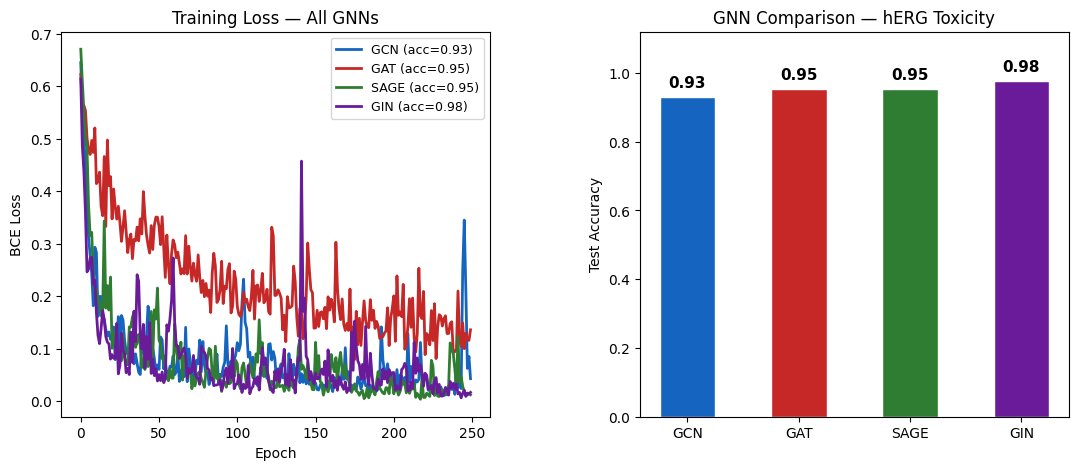


Per-molecule predictions  (GIN — best model):
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: hERG blocker   Pred: hERG blocker   Score: 1.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: hERG blocker   Pred: hERG blocker   Score: 1.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.370
  [OK]  True: hERG blocker   Pred: hERG blocker   Score: 1.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [XX]  True: hERG blocker   Pred: non-blocker    Score: 0.005
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: non-blocker    Pred: non-blocker    Score: 0.000
  [OK]  True: hERG blocker   Pred: hERG blocker   Score: 1.000
  [OK]  True: hERG blocker   Pred: hERG blocker   Score: 1.000
  [OK]  

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Summary accuracy table ─────────────────────────────────────────────────────
print(f"\n{'Model':<12}  {'Test Accuracy':>13}  {'Correct / Total':>15}")
print("─" * 46)
for name, (_, losses, acc, preds, labels) in results.items():
    correct = sum((p > 0.5) == (t == 1) for p, t in zip(preds, labels))
    print(f"  {name:<10}  {acc:>13.3f}  {correct:>7} / {len(labels):<7}")

# ── Comparison plots ───────────────────────────────────────────────────────────
# Each architecture gets a consistent colour used in both panels.
COLORS = {"GCN": "#1565c0", "GAT": "#c62828", "SAGE": "#2e7d32", "GIN": "#6a1b9a"}

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left panel: training loss curves ─────────────────────────────────────────
# Overlaying all four curves makes convergence speed and stability easy to compare.
ax1 = fig.add_subplot(gs[0])
for name, (_, losses, acc, _, _) in results.items():
    ax1.plot(losses, label=f"{name} (acc={acc:.2f})", color=COLORS[name], lw=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Training Loss — All GNNs"); ax1.legend(fontsize=9)

# ── Right panel: bar chart of final test accuracy ─────────────────────────────
ax2 = fig.add_subplot(gs[1])
names = list(results.keys())
accs  = [results[n][2] for n in names]
bars  = ax2.bar(names, accs, color=[COLORS[n] for n in names],
                width=0.5, edgecolor="white")
ax2.set_ylim(0, 1.12); ax2.set_ylabel("Test Accuracy")
ax2.set_title("GNN Comparison — hERG Toxicity")
# Annotate each bar with its numeric accuracy so the difference is immediately readable
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width() / 2, acc + 0.02,
             f"{acc:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.savefig("gnn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-molecule breakdown for the best model ─────────────────────────────────
# Identifies the winner by test accuracy and prints its per-molecule predictions.
best_name = max(results, key=lambda n: results[n][2])
_, _, _, best_preds, best_labels = results[best_name]
print(f"\nPer-molecule predictions  ({best_name} — best model):")
label_names = {0: "non-blocker", 1: "hERG blocker"}
for p, t in zip(best_preds, best_labels):
    pred_cls = 1 if p > 0.5 else 0
    match    = "OK" if pred_cls == int(t) else "XX"
    print(f"  [{match}]  True: {label_names[int(t)]:13s}  Pred: {label_names[pred_cls]:13s}  Score: {p:.3f}")

## Key takeaways

**Architecture comparison**

| Architecture | Aggregation | Strength | Weakness |
|---|---|---|---|
| GCN | Degree-normalised mean | Fast, easy to tune | All neighbours weighted equally |
| GAT | Learned attention (multi-head) | Focuses on relevant bonds | More parameters; can overfit small data |
| GraphSAGE | Concat(self, mean-nbrs) | Inductive; stable on varied graph sizes | Mean aggregation loses structural detail |
| GIN | MLP((1+ε)·self + Σ nbrs) | Maximally expressive (WL-test) | Largest parameter count; needs more data to shine |

**Practical notes**
- `global_mean_pool` collapses all per-atom embeddings into one fixed-size graph vector — the bridge between node-level message passing and graph-level prediction.
- On small datasets (< 500 molecules) all four architectures often score within a few percent of each other; GIN's theoretical advantage emerges at scale (> 5 k compounds).
- GAT's attention weights are interpretable: you can visualise which bonds the model finds important for hERG binding.
- For production drug discovery on small data, use **transfer learning** from pre-trained GNNs (DeepChem, GROVER, Uni-Mol) instead of training from scratch.